In [21]:
!pip install langgraph langchain langchain-google-genai google-generativeai


**USE CASE 1: Telecom SIM Activation & Fraud Verification Workflow**

In [22]:
from typing import TypedDict
from langgraph.graph import StateGraph, END
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.tools import tool


In [ ]:
import os

os.environ["GOOGLE_API_KEY"] = "AIzaSyDweDiQD2zNCMli2sbYyzCF54QaZTe8"

llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
)

In [24]:
class SIMActivationState(TypedDict):

    customer_name: str
    aadhaar_status: str
    pan_status: str
    location: str
    previous_sim_requests: int

    kyc_status: str
    fraud_risk: str
    final_decision: str

In [25]:
@tool
def kyc_verification_tool(aadhar_status: str,pan_status:str)->SIMActivationState:
    """this tool verifies the KYC status of the customer"""
    if (
        aadhar_status == "VALID"
        and pan_status == "VALID"
    ):
        return "VERIFIED"

    elif (
        aadhar_status == "PENDING"
        or pan_status == "PENDING"
    ):
       return "PENDING_VERIFICATION"

    else:
        return "INVALID_DOCUMENT"


In [33]:
def kyc_check(state:SIMActivationState)->SIMActivationState:
    result=kyc_verification_tool.invoke({'aadhar_status':state["aadhaar_status"],'pan_status':state["pan_status"]})
    state["kyc_status"]=result
    return state

In [27]:
def fraud_detection(state: SIMActivationState):

    prompt = f"""
    Analyze telecom SIM fraud risk.
    if more than 10 sim request it should be considered as high risk.

    Customer Location: {state["location"]}
    Previous SIM Requests: {state["previous_sim_requests"]}
    KYC Status: {state["kyc_status"]}

    Return ONLY one:
    LOW_RISK
    MEDIUM_RISK
    HIGH_RISK
    """

    response = llm.invoke(prompt)

    state["fraud_risk"] = response.content.strip()

    return state

In [28]:
def activation_decision(state: SIMActivationState):

    risk = state["fraud_risk"]

    if risk == "LOW_RISK":
        state["final_decision"] = "SIM Activated"

    elif risk == "MEDIUM_RISK":
        state["final_decision"] = "Manual Review"

    else:
        state["final_decision"] = "Reject Application"

    return state

In [34]:
graph = StateGraph(SIMActivationState)

graph.add_node("kyc_check", kyc_check)

graph.add_node("fraud_analysis", fraud_detection)

graph.add_node("final_decision", activation_decision)

In [35]:
graph.set_entry_point("kyc_check")
graph.add_edge("kyc_check", "fraud_analysis")
graph.add_edge("fraud_analysis", "final_decision")
graph.add_edge('final_decision',END)

workflow=graph.compile()


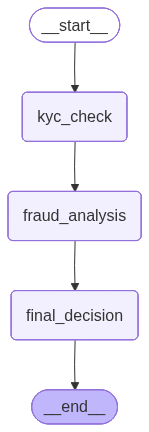

In [31]:
workflow

In [38]:
result = workflow.invoke({

    "customer_name": "Rahul",

    "aadhaar_status": "VALID",

    "pan_status": "VALID",

    "location": "Delhi",

    "previous_sim_requests": 11
})

print(result)

{'customer_name': 'Rahul', 'aadhaar_status': 'VALID', 'pan_status': 'VALID', 'location': 'Delhi', 'previous_sim_requests': 11, 'kyc_status': 'VERIFIED', 'fraud_risk': 'HIGH_RISK', 'final_decision': 'Reject Application'}


**USE CASE 2: Healthcare Appointment Prioritization Workflow**

In [39]:
# State Definition

class HealthcareState(TypedDict):

    patient_name: str
    fever: int
    oxygen_level: int
    heart_rate: int
    symptom_duration: int
    age: int
    existing_conditions: str

    severity_status: str
    priority_level: str
    consultation_type: str

In [43]:
@tool
def symptom_severity_tool(fever,oxygen_level,heart_rate,symptom_duration)->str:
    """this tool measures the severity of symptoms of ths patient by analyzing fever, oxygen level,heart rate and symptom duration"""
    if oxygen_level < 90 or heart_rate > 130:
        return "CRITICAL"

    elif fever > 101 or symptom_duration > 5:
        return "MODERATE"

    else:
        return "STABLE"

In [44]:
# Severity Analysis Node

def severity_check(state: HealthcareState) -> HealthcareState:

    result = symptom_severity_tool.invoke({
        'fever':state["fever"],
        'oxygen_level':state["oxygen_level"],
        'heart_rate':state["heart_rate"],
        'symptom_duration':state["symptom_duration"]}
    )

    state["severity_status"] = result

    return state

In [45]:
# Step 2 — Gemini Medical Prioritization

def medical_prioritization(
    state: HealthcareState
) -> HealthcareState:

    prompt = f"""
    Analyze the patient condition.

    Severity Level: {state["severity_status"]}
    Patient Age: {state["age"]}
    Existing Conditions: {state["existing_conditions"]}

    Rules:
    - CRITICAL patients are EMERGENCY
    - Elderly patients with conditions are PRIORITY_CONSULTATION
    - Stable patients are REGULAR_CONSULTATION

    Return ONLY one:
    EMERGENCY
    PRIORITY_CONSULTATION
    REGULAR_CONSULTATION
    """

    response = llm.invoke(prompt)

    state["priority_level"] = response.content.strip()

    return state

In [46]:
# Step 3 — Final Consultation Assignment

def consultation_assignment(
    state: HealthcareState
) -> HealthcareState:

    priority = state["priority_level"]

    if priority == "EMERGENCY":
        state["consultation_type"] = "ICU/ER"

    elif priority == "PRIORITY_CONSULTATION":
        state["consultation_type"] = "Specialist Doctor"

    else:
        state["consultation_type"] = "General Physician"

    return state

In [47]:
#compiling nodes and edged to the workflow
graph=StateGraph(HealthcareState)

graph.add_node('severity_check',severity_check)
graph.add_node('medical_prioritization',medical_prioritization)
graph.add_node('consultation_assignment',consultation_assignment)

graph.set_entry_point('severity_check')
graph.add_edge('severity_check','medical_prioritization')
graph.add_edge('medical_prioritization','consultation_assignment')
graph.add_edge('consultation_assignment',END)

workflow=graph.compile()

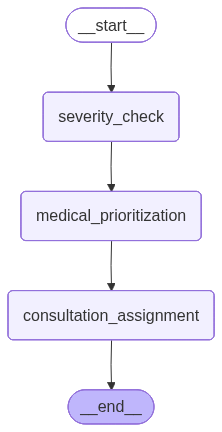

In [48]:
workflow

In [50]:
# Invoke Workflow

result = workflow.invoke({

    "patient_name": "Arjun",

    "fever": 103,

    "oxygen_level": 88,

    "heart_rate": 140,

    "symptom_duration": 7,

    "age": 65,

    "existing_conditions": "Diabetes"
})
print(result)

{'patient_name': 'Arjun', 'fever': 103, 'oxygen_level': 88, 'heart_rate': 140, 'symptom_duration': 7, 'age': 65, 'existing_conditions': 'Diabetes', 'severity_status': 'CRITICAL', 'priority_level': 'EMERGENCY', 'consultation_type': 'ICU/ER'}
